# **Distance Estimator Model**

## **Project Setup**
### **Import libraries**
Import all basic libraries here. Additional libraries needed later in the notebook can be done at the code cells they are needed for.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats

### **Load data**
Load all 7 indoor environment datasets into a single dataframe

In [3]:
# Dataset directory
dataset_path = "../dataset/"

# Retrieve all csv files in the dataset folder
csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]

# Load and merge all datasets
dfs = [pd.read_csv(os.path.join(dataset_path, file)) for file in csv_files]
df = pd.concat(dfs, ignore_index=True)

Reading the shape and columns of the dataframe provides information on all the data.

In [4]:
# Print data information
print(f'Number of rows and columns in dataset: {df.shape}')
print()
print(f'Columns in dataset: {df.columns}')

Number of rows and columns in dataset: (42000, 1031)

Columns in dataset: Index(['NLOS', 'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3',
       'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC',
       ...
       'CIR1006', 'CIR1007', 'CIR1008', 'CIR1009', 'CIR1010', 'CIR1011',
       'CIR1012', 'CIR1013', 'CIR1014', 'CIR1015'],
      dtype='object', length=1031)


## **Data Preparation (Data cleaning & Data preprocessing)**

### **Data Cleaning**
For data cleaning, we counted the total number of missing (NaN) values in the dataframe. If there is existing missing values, the rows are dropped and the new dataframe is returned to df_cleaned.

In [5]:
missingValCount = df.isnull().sum().sum()

if missingValCount > 0:
    df_cleaned = df.dropna()
    print(f'{missingValCount} missing values found and removed from dataset')
else:
    df_cleaned = df.copy()
    print('No missing values found in dataset')

No missing values found in dataset


For further data cleaning, we are detecting outliers to remove biasness and reduce error during data mining. The features **'RANGE', 'FP_AMP1', 'FP_AMP2', and 'FP_AMP3'** are chosen for outlier detection as these features are important to training the distance estimation model and are likely to have noise when retrieving data. <br>

We used boxplot to visualize the distribution of data on the selected features and used IQR to detect the outliers as IQR avoids removing too much valid data while handling extreme values.

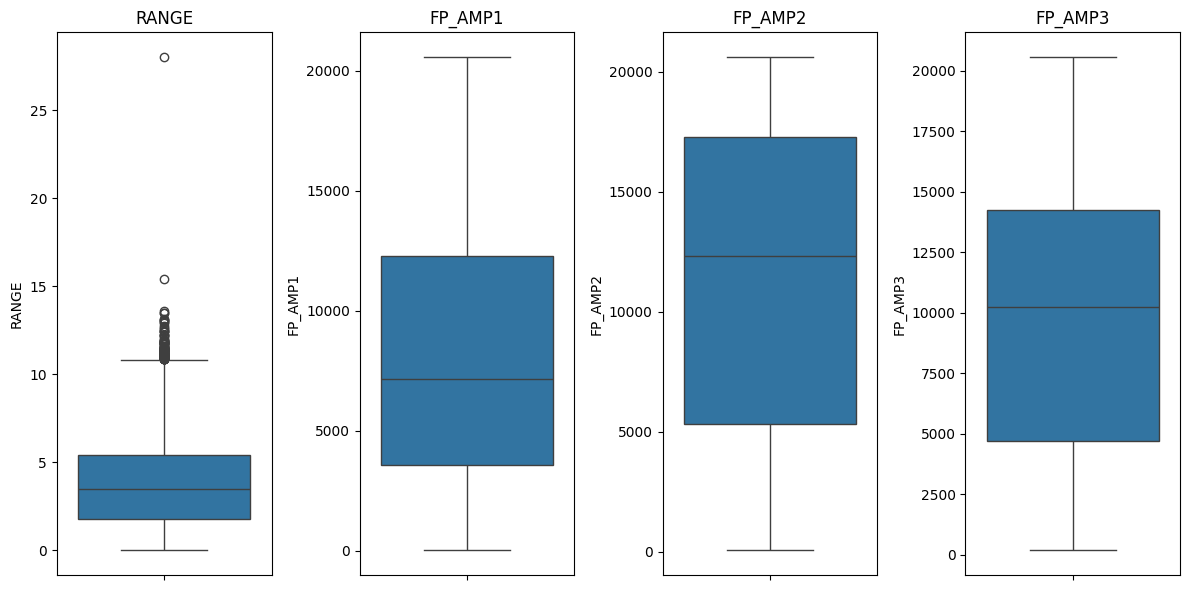

In [18]:
# Select key features for outlier detection
features = ["RANGE", "FP_AMP1", "FP_AMP2", "FP_AMP3"]

# Plot boxplots
plt.figure(figsize=(12, 6))
for i, feature in enumerate(features, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=df[feature])
    plt.title(feature)
plt.tight_layout()
plt.show()

In [ ]:
# Determine Q1 and Q2 of features
Q1 = df[features].quantile(0.25)
Q3 = df[features].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count outliers per feature
outlier_counts = ((df[features] < lower_bound) | (df[features] > upper_bound)).sum()

# Total number of outliers between all features
total_outliers = outlier_counts.sum()

print("Outlier count per feature:")
print(outlier_counts)
print(f"Total outliers across all features: {total_outliers}")

# Mask for outliers
outlier_mask = ((df[features] < lower_bound) | (df[features] > upper_bound)).any(axis=1)

# Remove outliers
df_cleaned = df.loc[outlier_mask != True]

print(f"Dataset shape after removing outliers: {df_cleaned.shape}")

Outlier count per feature:
RANGE      121
FP_AMP1      0
FP_AMP2      0
FP_AMP3      0
dtype: int64
Total outliers across all features: 121
Dataset shape after removing outliers: (41879, 1031)


### **Data Preprocessing (PCA)**

PCA on 1016 CIR values for feature reduction

In [22]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# All CIR features
cir_columns = [f"CIR{i}" for i in range(1016)]
X_cir = df[cir_columns]

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cir)

# PCA - number of dimensions still tbc, need to do more analysis
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

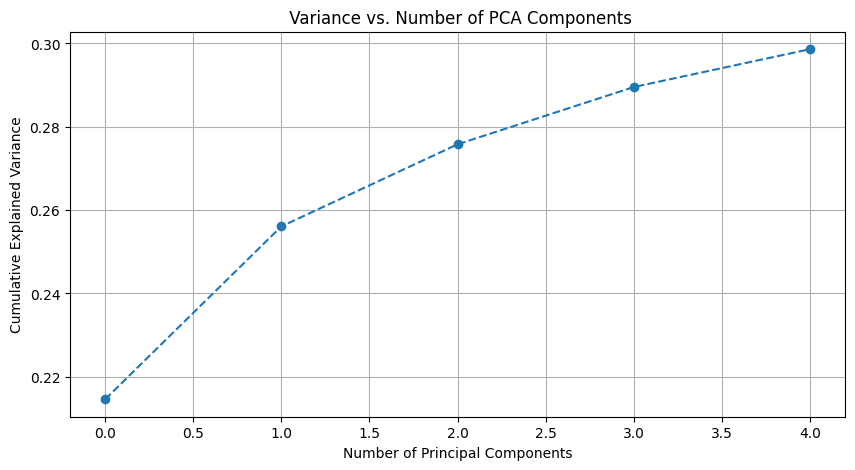

Number of components to retain 95% variance: 862


In [23]:
# Variance plot
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title(" Variance vs. Number of PCA Components")
plt.grid()
plt.show()

# Number of components to retain 95% variance -- variance also tbc
pca_95 = PCA(0.95)
X_pca_95 = pca_95.fit_transform(X_scaled)
print(f"Number of components to retain 95% variance: {pca_95.n_components_}")